Tomando como base la libreta de kaggle de [Anomaly Detection using PatchCore from Scratch](https://www.kaggle.com/code/akshaysom/anomaly-detection-using-patchcore-from-scratch) pero cambiando el conjunto de dataset del `hazelnut` al `grid`

In [185]:
import os, shutil
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchvision.models import resnet50, ResNet50_Weights

# Arquitectura

In [186]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [187]:
class resnet_feature_extractor(torch.nn.Module):
    def __init__(self):
        """This class extracts the feature maps from a pretrained Resnet model."""
        super(resnet_feature_extractor, self).__init__()
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        
        # Hook to extract feature maps
        def hook(module, input, output) -> None:
            """This hook saves the extracted feature map on self.featured."""
            self.features.append(output)

        self.model.layer2[-1].register_forward_hook(hook)            
        self.model.layer3[-1].register_forward_hook(hook) 

    def forward(self, input):

        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride=1)
        fmap_size = self.features[0].shape[-2]         # Feature map sizes h, w
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)            # Merge the resized feature maps
        patch = patch.reshape(patch.shape[1], -1).T   # Craete a column tensor

        return patch

In [188]:
def getImage(path):
    """This function reads an image from a path and applies the transformation."""
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0).cuda()

Feature layer 1 shape: torch.Size([1, 512, 28, 28])
Feature layer 2 shape: torch.Size([1, 1024, 14, 14])
Feature shape: torch.Size([784, 1536])


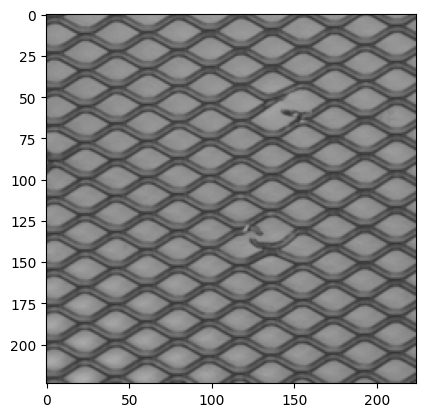

In [189]:
backbone = resnet_feature_extractor().cuda()

sample_img_path = '/home/jamor/redes/MVTec-AD/data/raw/grid/test/broken/000.png'
image = getImage(sample_img_path)

feature = backbone(image)

print(f'Feature layer 1 shape: {backbone.features[0].shape}')
print(f'Feature layer 2 shape: {backbone.features[1].shape}')

print(f'Feature shape: {feature.shape}')

plt.imshow(image[0].cpu().permute(1,2,0), cmap='gray')
plt.show()

# Entrenamiento

In [190]:
memory_bank = []

folder_path = Path(r'/home/jamor/redes/MVTec-AD/data/raw/grid/train/good')

for pth in tqdm(folder_path.iterdir(),leave=False):
    # print(pth)
    with torch.no_grad():
        data = getImage(pth)
        features = backbone(data)
        # print(features.shape)
        memory_bank.append(features.cpu().detach())

print(f'Number of features in memory bank: {len(memory_bank)}')
print(f'Feature shape: {memory_bank[0].shape}')
memory_bank = torch.cat(memory_bank,dim=0).cuda()
print(f'Memory bank shape: {memory_bank.shape}') # 784x391 = 306544

0it [00:00, ?it/s]

Number of features in memory bank: 264
Feature shape: torch.Size([784, 1536])
Memory bank shape: torch.Size([206976, 1536])


In [191]:
selected_indices = np.random.choice(len(memory_bank), size=len(memory_bank)//10, replace=False)
memory_bank = memory_bank[selected_indices]
print(f'New memory bank shape: {memory_bank.shape}')

New memory bank shape: torch.Size([20697, 1536])


In [192]:
def anomaly_map(data,test=True):
    """This function computes the anomaly map for a given feature and a memory bank."""
    with torch.no_grad():
        features = backbone(data)
        # print(features.shape)
    distances = torch.cdist(features, memory_bank, p=2.0)
    # print(distances.shape)
    dist_score, dist_score_idxs = torch.min(distances, dim=1) 
    # print(dist_score[:10], dist_score_idxs[:10])
    s_star = torch.max(dist_score)
    # print(s_star)
    segm_map = dist_score.view(1, 1, 28, 28) 
    # print(segm_map.shape)
    if test:
        # Upscale by bi-linaer interpolation to match the original input resolution
        segm_map = torch.nn.functional.interpolate(
            segm_map,
            size=(224, 224),
            mode='bilinear'
            )
    return segm_map, s_star

In [193]:
y_score_good = []
folder_path = Path(r'/home/jamor/redes/MVTec-AD/data/raw/grid/train/good')

for pth in tqdm(folder_path.iterdir(),leave=False):
    data = getImage(pth)
    # print(data.shape)
    segm_map, s_star = anomaly_map(data,False)

    y_score_good.append(s_star.cpu().numpy())
    # break

y_score_good[:5]

0it [00:00, ?it/s]

[array(11.136899, dtype=float32),
 array(8.404653, dtype=float32),
 array(10.089891, dtype=float32),
 array(9.530769, dtype=float32),
 array(9.799928, dtype=float32)]

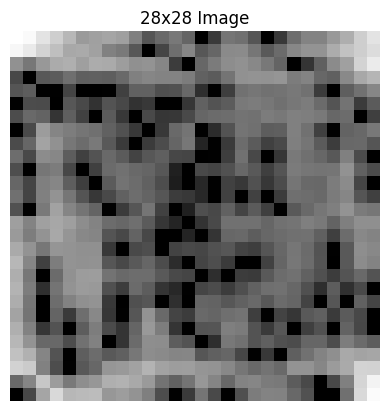

In [194]:
image_np = segm_map.squeeze().cpu() # Remove batch & channel dimensions

# Plot the image
plt.imshow(image_np, cmap='gray')
plt.title("28x28 Image")
plt.axis("off")  # Hide axes
plt.show()

Mean: 10.023574829101562
Variance: 0.9801369309425354
Threshold: 12.963985443115234


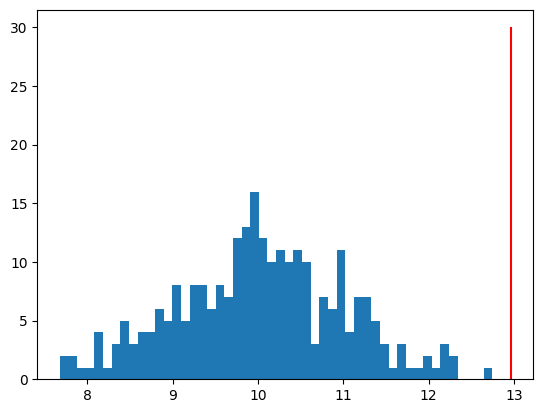

In [195]:
print(f'Mean: {np.mean(y_score_good)}')
print(f'Variance: {np.std(y_score_good)}')

best_threshold = np.mean(y_score_good) + 3 * np.std(y_score_good)
print(f"Threshold: {best_threshold}")

plt.hist(y_score_good, bins=50)
plt.vlines(x=best_threshold, ymin=0, ymax=30, color='r')
plt.show()

# Prueba

In [196]:
y_score = []
y_true = []
path = "/home/jamor/redes/MVTec-AD/data/raw/grid/test"
contents = os.listdir(path)
for classes in contents:
    folder_path_test = Path(f"{path}/{classes}")
    
    for pth in tqdm(folder_path_test.iterdir(),leave=False):
        # print(pth)
        class_label = pth.parts[-2]
        # print(class_label)
        test_image = getImage(pth)
        segm_map, s_star = anomaly_map(test_image)

        y_score.append(s_star.cpu().numpy())
        y_true.append(0 if class_label=='good' else 1)  # 0 -> GOOD, 1 -> BAD
        # break

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

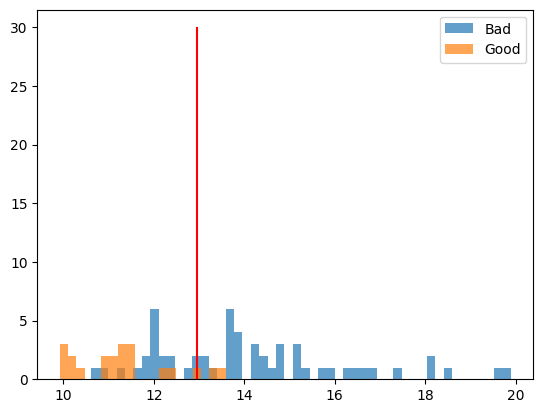

In [197]:
y_score_bad = [score for score,true in zip(y_score, y_true) if true==1]
y_score_good = [score for score,true in zip(y_score, y_true) if true==0]
plt.hist(y_score_bad,bins=50,alpha=0.7,label='Bad')
plt.hist(y_score_good,bins=20, alpha=0.7,label='Good')
plt.vlines(x=best_threshold,ymin=0,ymax=30,color='r')
plt.legend()
plt.show()

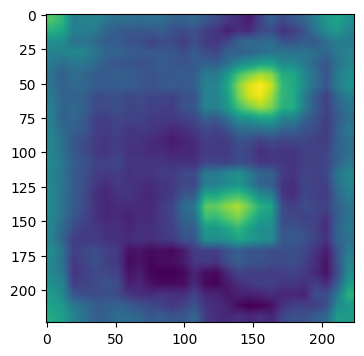

In [198]:
test_image = getImage(f'{path}/broken/000.png')
segm_map, s_star = anomaly_map(test_image)

plt.figure(figsize=(4,4))
plt.imshow(segm_map.cpu().squeeze())
plt.show()

AUC-ROC Score: 0.9030910609857978
fpr, tpr, thresholds:  [0.         0.         0.         0.0952381  0.0952381  0.14285714
 0.14285714 0.23809524 0.23809524 0.47619048 0.47619048 0.71428571
 0.71428571 1.        ] [0.         0.01754386 0.61403509 0.61403509 0.66666667 0.66666667
 0.75438596 0.75438596 0.94736842 0.94736842 0.96491228 0.96491228
 1.         1.        ] [        inf 19.89430428 13.600564   13.24651241 13.06830692 12.91719341
 12.42864895 12.23360157 11.61755276 11.37528992 11.35932159 10.87755871
 10.61847782  9.92052174]
f1_scores: [0.0, 0.034482758620689655, 0.7608695652173914, 0.7446808510638298, 0.7835051546391752, 0.7755102040816326, 0.8349514563106796, 0.819047619047619, 0.9310344827586207, 0.8925619834710744, 0.9016393442622951, 0.8661417322834646, 0.8837209302325582, 0.8444444444444444]
best_threshold = 11.617552757263184


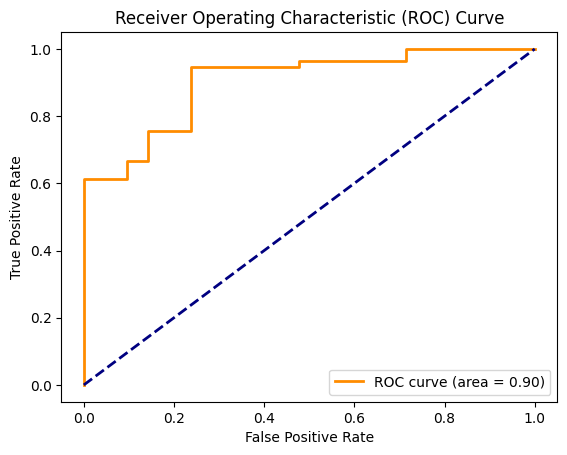

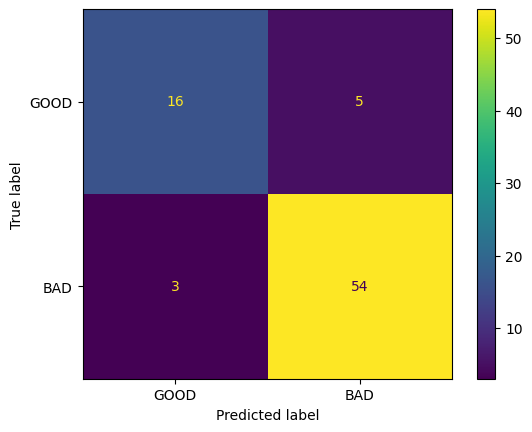

In [199]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Calculate AUC-ROC score
auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score:", auc_roc_score)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
print("fpr, tpr, thresholds: ", fpr, tpr, thresholds)

f1_scores = [f1_score(y_true, y_score >= threshold) for threshold in thresholds]
print("f1_scores:", f1_scores)

# Select the best threshold based on F1 score
best_threshold = thresholds[np.argmax(f1_scores)]

print(f'best_threshold = {best_threshold}')

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Generate confusion matrix
cm = confusion_matrix(y_true, (y_score >= best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['GOOD', 'BAD'])
disp.plot()
plt.show()

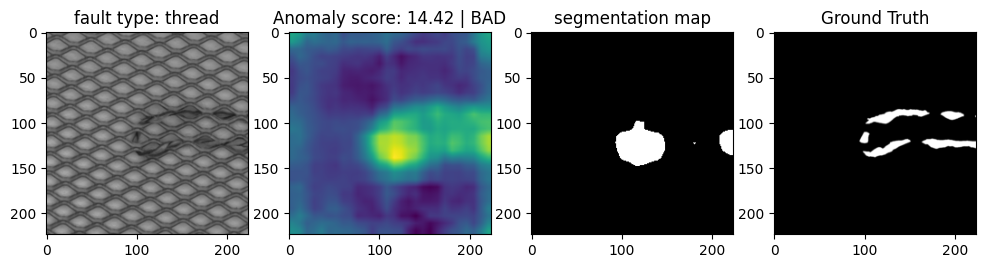

IoU 17.97


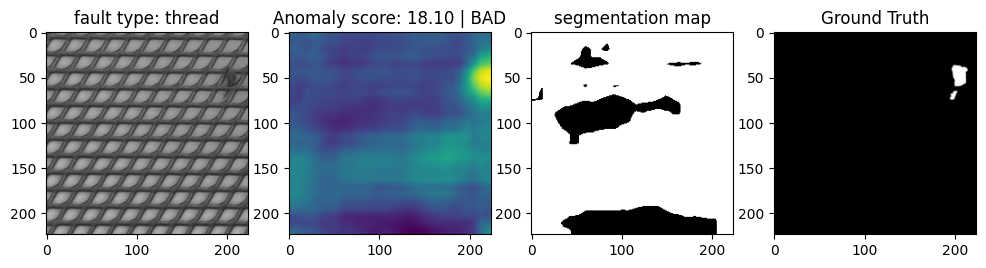

IoU 0.84


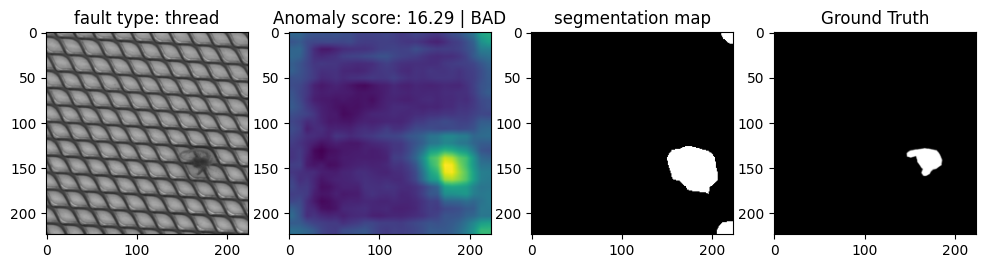

IoU 24.73


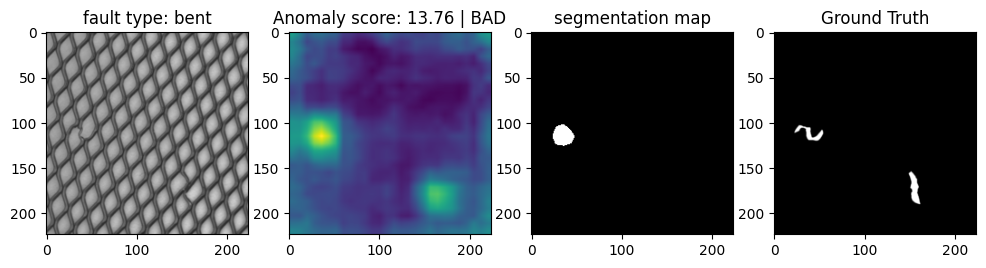

IoU 16.12


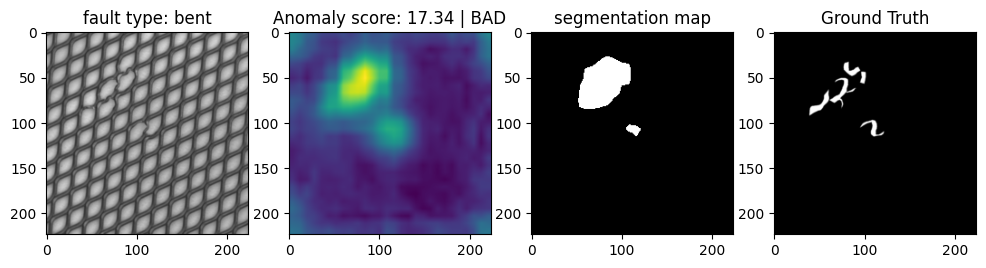

IoU 19.25


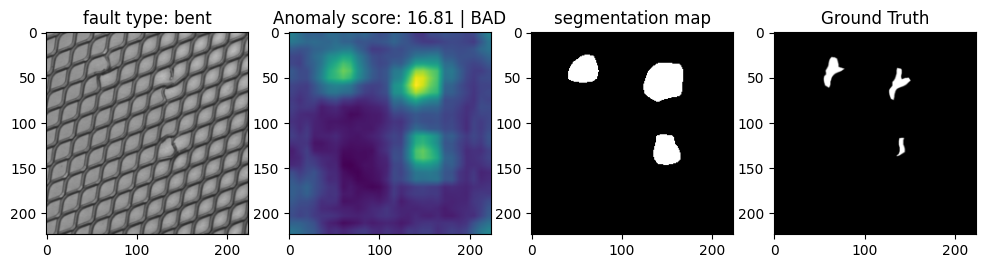

IoU 21.30


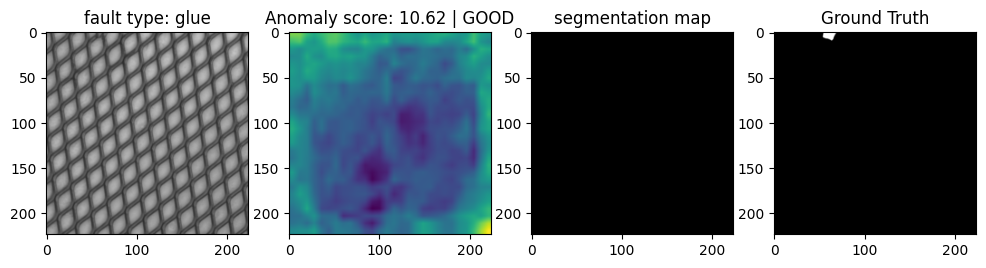

IoU 0.00


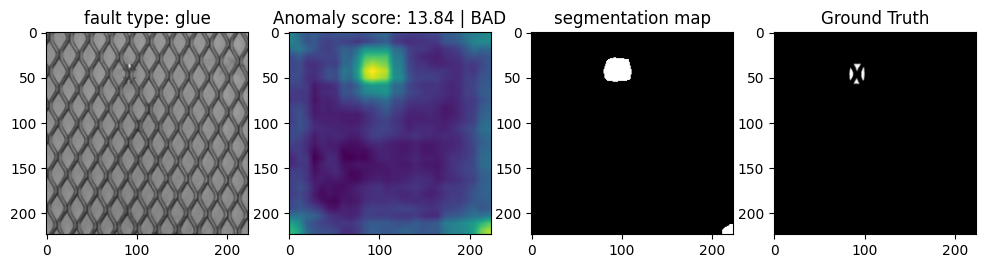

IoU 13.30


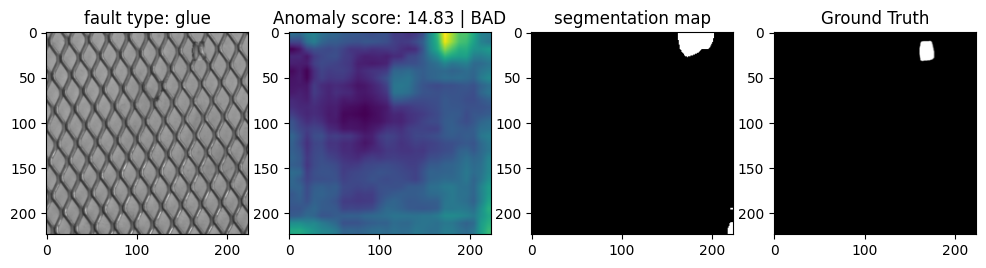

IoU 15.79


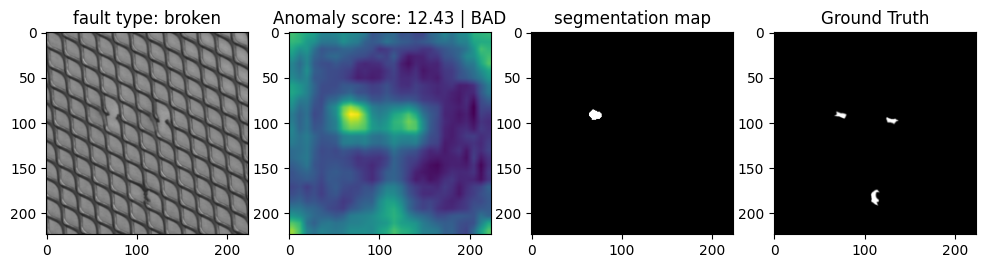

IoU 16.52


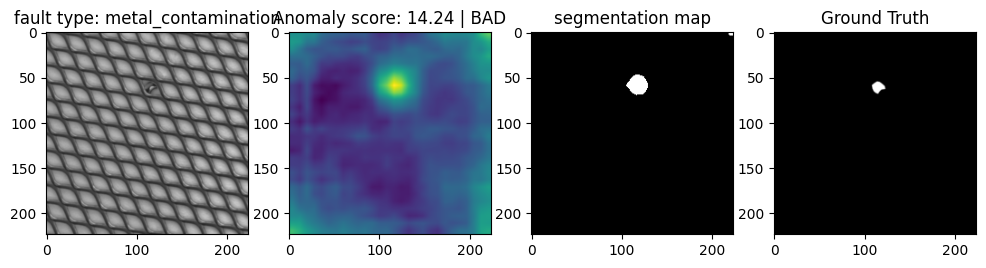

IoU 30.05


In [200]:
import cv2, time

backbone.eval()
class_label = ['GOOD', 'BAD']
path = "/home/jamor/redes/MVTec-AD/data/raw/grid/test"
contents = os.listdir(path)
test_path = Path(path)
contents.remove('good')
#print(contents)
labels = []
scores = []
ious = []

for path in test_path.glob('*/*.png'): 

    fault_type = path.parts[-2]
    if fault_type in contents: # de 0 a 5, ['thread', 'bent', 'glue', 'broken', 'metal_contamination', 'good']
        
        labels.append(fault_type)
        test_image = getImage(path)
        
        segm_map, s_star = anomaly_map(test_image)
        # Upscale by bi-linear interpolation to match the original input resolution
        segm_map = segm_map.cpu().squeeze().numpy()
        
        y_score_image = s_star.cpu().numpy()  
        scores.append(y_score_image)
        y_pred_image = 1*(y_score_image>=best_threshold)
        ground_truth = getImage(Path(str(path).replace("/test/","/ground_truth/").replace(".png", "_mask.png"))).squeeze().permute(1,2,0).cpu().numpy()
        heat_map = segm_map
        segmentation = heat_map > best_threshold
        and_map = segmentation * ground_truth[:,:,0]
        or_map = segmentation + ground_truth[:,:,0] - and_map
        iou = 100*(and_map).sum(axis=(0,1))/(or_map).sum(axis=(0,1))
        ious.append(iou)
        if(np.random.rand() < 0.1):
            plt.figure(figsize=(12,3))
            plt.subplot(1,4,1)
            plt.imshow(test_image.squeeze().permute(1,2,0).cpu().numpy())
            plt.title(f'fault type: {fault_type}')

            plt.subplot(1,4,2)
            
            plt.imshow(heat_map) 
            plt.title(f'Anomaly score: {y_score_image:0.2f} | {class_label[y_pred_image]}')
            
            

            plt.subplot(1,4,3)
            plt.imshow(segmentation, cmap='gray')  #
            plt.title(f'segmentation map')

            plt.subplot(1,4,4)
            #plt.hist(heat_map.flatten(), bins=50)
            plt.imshow(ground_truth, cmap='gray')
            plt.title(f'Ground Truth')

            
            plt.show()
            
            print(f'IoU {iou:0.2f}')

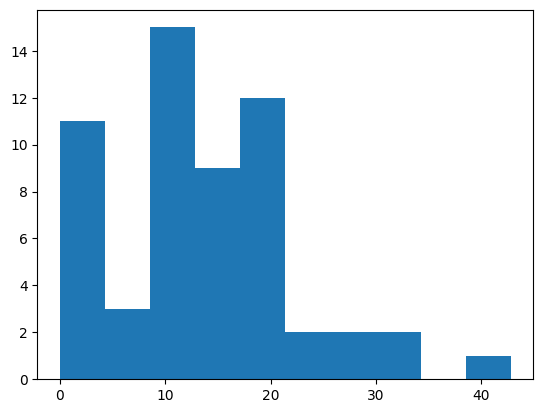

In [201]:
plt.hist(ious)
plt.show()

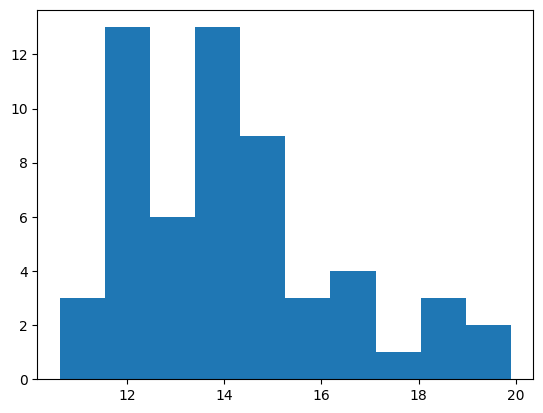

In [202]:
plt.hist(scores)
plt.show()